# **LBLDE and DP-LLDE Testing Notebook**
**Level-Based Learning Differential Evolution — Google Colab**

**Diversity-Preserving Level-Guided Learning Differential Evolution - Google Colab**

This notebook tests the LBLDE algorithm on classical benchmark functions and CEC 2017 functions.

---
# **1. LBLDE**

---



## **1.1. Setup and Installation**


---



Install `opfunu` to import CEC 2017 Benchmark Functions

In [ ]:
!pip install opfunu numpy scipy --quiet
print("All packages installed successfully!")

All packages installed successfully!


Import `files` and `os` for uploading a file to the environment's file system

In [ ]:
from google.colab import files
import os

View if `lblde.py` is already uploaded or not. If no, then request attachment upload

In [ ]:
if not os.path.exists('lblde.py'):
    print("Please upload lblde.py when the dialog appears...")
    uploaded = files.upload()
    if 'lblde.py' in uploaded:
        print("lblde.py uploaded successfully!")
    else:
        print("lblde.py was not found in the upload. Please try again.")
else:
    print("lblde.py already present in the session.")

lblde.py already present in the session.


Import `np`, `sys`, and `warnings` system-level operations, and control over warning messages

In [ ]:
import numpy as np
import sys
import warnings

This code suppresses warning messages and ensures the current directory is included in Python’s system path so that `lblde.py`can be imported.


> Imports `run_multiple_trials`



In [ ]:
warnings.filterwarnings('ignore')

# Add current directory to path so lblde.py is importable
if '.' not in sys.path:
    sys.path.insert(0, '.')

try:
    from lblde import LBLDE, run_multiple_trials
    print("LBLDE imported successfully!")
except ImportError as e:
    print(f"Import failed: {e}")
    print("  Make sure lblde.py is uploaded and in the current directory.")

LBLDE imported successfully!



## **1.2. Test 1 — Basic Benchmark Functions**


---



Define 3 basic benchmark functions for testing

In [ ]:
def sphere(x):
    return np.sum(x**2)

def rastrigin(x):
    n = len(x)
    return 10*n + np.sum(x**2 - 10*np.cos(2*np.pi*x))

def rosenbrock(x):
    return np.sum(100*(x[1:] - x[:-1]**2)**2 + (1 - x[:-1])**2)

print("Benchmark functions defined.")

Benchmark functions defined.


Tests LBLDE on three classical functions: **Sphere**, **Rastrigin**, and **Rosenbrock**.

In [ ]:
print("="*80)
print("Testing LBLDE on Basic Benchmark Functions")
print("="*80)

D = 10
tests = [
    ("Sphere",     sphere,     [-100,   100]),
    ("Rastrigin",  rastrigin,  [-5.12, 5.12]),
    ("Rosenbrock", rosenbrock, [-30,    30]),
]

for name, func, bound_range in tests:
    print(f"\n{'-'*80}")
    print(f"Function: {name} ({D}D)")
    print(f"{'-'*80}")

    bounds = np.array([bound_range] * D)

    optimizer = LBLDE(
        objective_func=func,
        bounds=bounds,
        NP=100,
        NL=4,
        NLB=1,
        mu_CR_ini=0.35,
        max_fes=10000 * D,
        seed=42
    )

    best_sol, best_fit, history = optimizer.optimize(verbose=False)

    print(f"  Best Fitness   : {best_fit:.6e}")
    print(f"  Generations    : {len(history)}")

print("\n" + "="*80)
print("Basic tests completed!")
print("="*80)

Testing LBLDE on Basic Benchmark Functions

--------------------------------------------------------------------------------
Function: Sphere (10D)
--------------------------------------------------------------------------------
  Best Fitness   : 4.822855e-90
  Generations    : 1000

--------------------------------------------------------------------------------
Function: Rastrigin (10D)
--------------------------------------------------------------------------------
  Best Fitness   : 0.000000e+00
  Generations    : 1000

--------------------------------------------------------------------------------
Function: Rosenbrock (10D)
--------------------------------------------------------------------------------
  Best Fitness   : 0.000000e+00
  Generations    : 1000

Basic tests completed!


## **1.3. Test 2 — Single CEC 2017 Function (F1)**


---



Run a single optimisation trial on **F1** (Shifted and Rotated Bent Cigar) and reports the error against the known global optimum.

In [ ]:
print("="*80)
print("Testing LBLDE on CEC 2017 F1")
print("="*80)

try:
    from opfunu.cec_based import cec2017
    print("opfunu CEC 2017 library loaded")
except ImportError:
    raise SystemExit("opfunu not found. Re-run the installation cell at the top.")

D = 10
print(f"\nFunction : F1 — Shifted and Rotated Bent Cigar ({D}D)")

func_obj = cec2017.F12017(ndim=D)
print(f"Bounds         : {func_obj.bounds[0]}")
print(f"Global optimum : {func_obj.f_global}")

print("\nRunning LBLDE...")
optimizer = LBLDE(
    objective_func=func_obj.evaluate,
    bounds=func_obj.bounds,
    NP=100,
    NL=4,
    NLB=1,
    mu_CR_ini=0.35,
    max_fes=10000 * D,
    seed=42
)

best_sol, best_fit, history = optimizer.optimize(verbose=True)

error = best_fit - func_obj.f_global

print(f"\n{'='*80}")
print("Results:")
print(f"  Best Fitness   : {best_fit:.6e}")
print(f"  Global Optimum : {func_obj.f_global:.6e}")
print(f"  Error          : {error:.6e}")
print(f"  Best Solution (first 5 dims): {best_sol[:5]}")
print(f"{'='*80}")

Testing LBLDE on CEC 2017 F1
opfunu CEC 2017 library loaded

Function : F1 — Shifted and Rotated Bent Cigar (10D)
Bounds         : [-100.  100.]
Global optimum : 100.0

Running LBLDE...
Generation 0: Best Fitness = 1.871674e+10
Generation 10: Best Fitness = 1.334429e+09, FES = 1100
Generation 20: Best Fitness = 1.429221e+08, FES = 2100
Generation 30: Best Fitness = 2.881740e+07, FES = 3100
Generation 40: Best Fitness = 5.067489e+06, FES = 4100
Generation 50: Best Fitness = 8.460063e+05, FES = 5100
Generation 60: Best Fitness = 2.279326e+05, FES = 6100
Generation 70: Best Fitness = 7.909739e+04, FES = 7100
Generation 80: Best Fitness = 3.898910e+04, FES = 8100
Generation 90: Best Fitness = 7.023667e+03, FES = 9100
Generation 100: Best Fitness = 3.360094e+03, FES = 10100
Generation 110: Best Fitness = 8.619206e+02, FES = 11100
Generation 120: Best Fitness = 5.383522e+02, FES = 12100
Generation 130: Best Fitness = 2.395506e+02, FES = 13100
Generation 140: Best Fitness = 1.318351e+02, FES 

## **1.4. Test 3 — Multiple Runs on CEC 2017 F1 (51 runs)**


---




Replicates the paper's protocol: **51 independent runs** on F1 (Shifted and Rotated Bent Cigar) and reports mean / std / median / min / max error.

In [ ]:
print("="*80)
print("Multiple Runs Test (51 runs as in paper)")
print("="*80)

try:
    from opfunu.cec_based import cec2017
except ImportError:
    raise SystemExit("opfunu not found. Re-run the installation cell at the top.")

D      = 10
n_runs = 51   # As specified in the paper

print(f"\nFunction : F1 ({D}D)")
print(f"Runs     : {n_runs}")
print(f"Max FES  : {10000 * D}")

func_obj = cec2017.F12017(ndim=D)

print("\nRunning trials (this may take a few minutes)...")
results = run_multiple_trials(
    func=func_obj.evaluate,
    bounds=func_obj.bounds,
    D=D,
    n_runs=n_runs,
    max_fes=10000 * D,
    verbose=False
)

errors = results['all_best'] - func_obj.f_global

print(f"\n{'='*80}")
print("Statistical Results (Error = f(x*) − f_global):")
print(f"  Mean   : {np.mean(errors):.6e}")
print(f"  Std    : {np.std(errors):.6e}")
print(f"  Median : {np.median(errors):.6e}")
print(f"  Min    : {np.min(errors):.6e}")
print(f"  Max    : {np.max(errors):.6e}")
print(f"\n  Paper reference (F1, 10D): 0.00e+00 ± 0.00e+00")
print(f"{'='*80}")

## **1.5. Test 4 — Multiple CEC 2017 Functions (F1–F5)**

---




Run a single trial on **F1 - F5** and prints a summary error table.

In [ ]:
print("="*80)
print("Testing Multiple CEC 2017 Functions (F1–F5)")
print("="*80)

try:
    from opfunu.cec_based import cec2017
except ImportError:
    raise SystemExit("opfunu not found. Re-run the installation cell at the top.")

D = 10

functions = [
    (1, cec2017.F12017,  "Shifted and Rotated Bent Cigar"),
    (2, cec2017.F22017,  "Shifted and Rotated Sum of Different Power"),
    (3, cec2017.F32017,  "Shifted and Rotated Zakharov"),
    (4, cec2017.F42017,  "Shifted and Rotated Rosenbrock's"),
    (5, cec2017.F52017,  "Shifted and Rotated Rastrigin's"),
]

results_list = []

for func_num, FuncClass, func_name in functions:
    print(f"\n{'-'*80}")
    print(f"F{func_num}: {func_name} ({D}D)")
    print(f"{'-'*80}")

    func_obj = FuncClass(ndim=D)

    optimizer = LBLDE(
        objective_func=func_obj.evaluate,
        bounds=func_obj.bounds,
        NP=100,
        NL=4,
        NLB=1,
        mu_CR_ini=0.35,
        max_fes=10000 * D,
        seed=42
    )

    best_sol, best_fit, history = optimizer.optimize(verbose=False)
    error = best_fit - func_obj.f_global

    print(f"  Best Fitness : {best_fit:.6e}")
    print(f"  Error        : {error:.6e}")

    results_list.append({
        'Function': f'F{func_num}',
        'Name': func_name,
        'Best_Fitness': best_fit,
        'Error': error
    })

print(f"\n{'='*80}")
print("Summary of Results:")
print(f"{'='*80}")
print(f"{'Func':<6}  {'Error':>14}  Name")
print("-"*80)
for r in results_list:
    print(f"{r['Function']:<6}  {r['Error']:>14.6e}  {r['Name']}")
print(f"{'='*80}")

---
## Next Steps

- **Test all 30 CEC 2017 functions** — extend the `functions` list in Test 4 with `F62017` through `F302017`.
- **Higher dimensions** — change `D` to `30`, `50`, or `100` in any test cell.
- **Full paper experiment** — set `n_runs = 51` and loop over all 30 functions in Test 3's pattern.
- **Convergence plots** — use `matplotlib` on the `history` list returned by `optimizer.optimize()`.



---


# **2. DP-LLDE**

---



## **2.1. Setup and Installation**


---



Install `opfunu` to import CEC 2017 Benchmark Functions

In [ ]:
!pip install opfunu numpy scipy --quiet
print("All packages installed successfully!")

Import `files` and `os` for uploading a file to the environment's file system

In [ ]:
from google.colab import files
import os

View if `dpllde.py` is already uploaded or not. If no, then request attachment upload.

In [ ]:
for fname in ['dpllde.py']:
    if not os.path.exists(fname):
        print(f'Please upload {fname} when the dialog appears...')
        uploaded = files.upload()
        if fname in uploaded:
            print(f'{fname} uploaded.')
        else:
            print(f'{fname} not found in upload — please retry.')
    else:
        print(f'{fname} already present.')

dpllde.py already present.


Import `np`, `plt`, `sys`, and `warnings` system-level operations, and control over warning messages

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import sys, warnings

This code suppresses warning messages and ensures the current directory is included in Python’s system path so that `dpllde.py`can be imported.


> Imports `run_multiple_trials`, and other basic functions



In [ ]:
warnings.filterwarnings('ignore')

if '.' not in sys.path:
    sys.path.insert(0, '.')

try:
    from dpllde import DPLLDE, run_multiple_trials
    from dpllde import sphere, rastrigin, rosenbrock, ackley, griewank
    print('DPLLDE imported successfully!')
except ImportError as e:
    print(f'Import failed: {e}')
    print('  Make sure dpllde.py is uploaded and in the current directory.')

DPLLDE imported successfully!



## **2.2. Test 1 — Basic Benchmark Functions**


---



Tests DP-LLDE on five classical functions: **Sphere**, **Rastrigin**, **Rosenbrock**, **Ackley**, and **Griewank**.

In [ ]:
print('=' * 80)
print('DP-LLDE on Classical Benchmark Functions (10-D, single run)')
print('=' * 80)

D = 10
tests = [
    ('Sphere',     sphere,     [-100,   100],  0.0),
    ('Rastrigin',  rastrigin,  [-5.12, 5.12],  0.0),
    ('Rosenbrock', rosenbrock, [-30,    30],    0.0),
    ('Ackley',     ackley,     [-32,    32],    0.0),
    ('Griewank',   griewank,   [-600,   600],   0.0),
]

for name, func, bound_range, optimum in tests:
    bounds = np.array([bound_range] * D)
    opt = DPLLDE(
        objective_func=func, bounds=bounds,
        NP=100, NL=4, mu_CR_ini=0.5,
        max_fes=10000 * D, seed=42
    )
    _, best_fit, _ = opt.optimize(verbose=False)
    error = best_fit - optimum
    print(f'  {name:<12}: Best = {best_fit:.6e}  |  Error = {error:.6e}')

print('\nBasic tests completed!')

DP-LLDE on Classical Benchmark Functions (10-D, single run)
  Sphere      : Best = 9.640587e-118  |  Error = 9.640587e-118
  Rastrigin   : Best = 0.000000e+00  |  Error = 0.000000e+00
  Rosenbrock  : Best = 1.495469e-01  |  Error = 1.495469e-01
  Ackley      : Best = 3.996803e-15  |  Error = 3.996803e-15
  Griewank    : Best = 0.000000e+00  |  Error = 0.000000e+00

Basic tests completed!


Plot the best-fitness convergence

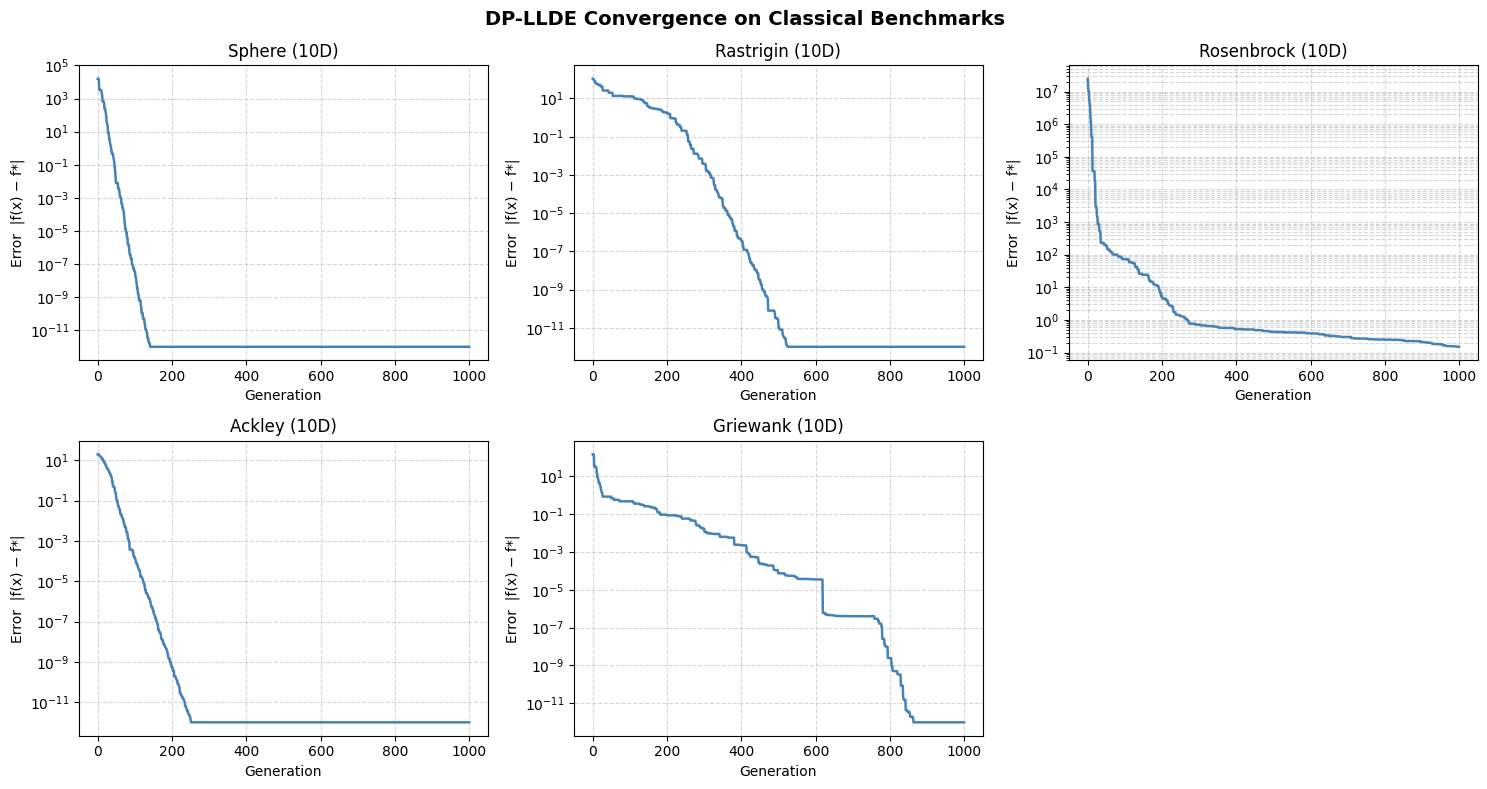

Convergence plot saved to convergence_classical.png


In [ ]:
D = 10
plot_tests = [
    ('Sphere',     sphere,     [-100,   100],  0.0),
    ('Rastrigin',  rastrigin,  [-5.12, 5.12],  0.0),
    ('Rosenbrock', rosenbrock, [-30,    30],    0.0),
    ('Ackley',     ackley,     [-32,    32],    0.0),
    ('Griewank',   griewank,   [-600,   600],   0.0),
]

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.ravel()

for ax, (name, func, bound_range, optimum) in zip(axes, plot_tests):
    bounds = np.array([bound_range] * D)
    opt = DPLLDE(
        objective_func=func, bounds=bounds,
        NP=100, NL=4, mu_CR_ini=0.5,
        max_fes=10000 * D, seed=42
    )
    _, _, history = opt.optimize(verbose=False)
    errors = [max(h - optimum, 1e-12) for h in history]

    ax.semilogy(errors, linewidth=1.8, color='steelblue')
    ax.set_title(f'{name} ({D}D)', fontsize=12)
    ax.set_xlabel('Generation')
    ax.set_ylabel('Error  |f(x) − f*|')
    ax.grid(True, which='both', linestyle='--', alpha=0.5)

# Hide unused subplot
axes[-1].set_visible(False)

plt.suptitle('DP-LLDE Convergence on Classical Benchmarks', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('convergence_classical.png', dpi=150, bbox_inches='tight')
plt.show()
print('Convergence plot saved to convergence_classical.png')


## **2.3. Test 2 — Single CEC 2017 Function (F1)**


---



Run a single optimisation trial on **F1** (Shifted and Rotated Bent Cigar) and reports the error against the known global optimum.

In [ ]:
print('=' * 80)
print('DP-LLDE on CEC 2017 F1 — Single Run')
print('=' * 80)

try:
    from opfunu.cec_based import cec2017
    print('opfunu CEC 2017 loaded!')
except ImportError:
    raise SystemExit('opfunu not found — re-run the installation cell.')

D = 10
func_obj = cec2017.F12017(ndim=D)
print(f'\nFunction       : F1 — Shifted and Rotated Bent Cigar ({D}D)')
print(f'Bounds         : {func_obj.bounds[0]}')
print(f'Global optimum : {func_obj.f_global}')

opt = DPLLDE(
    objective_func=func_obj.evaluate,
    bounds=func_obj.bounds,
    NP=100, NL=4, mu_CR_ini=0.5,
    max_fes=10000 * D,
    seed=42
)

best_sol, best_fit, history = opt.optimize(verbose=True)

error = best_fit - func_obj.f_global
print(f'\n{"="*80}')
print('Results:')
print(f'  Best Fitness          : {best_fit:.6e}')
print(f'  Global Optimum        : {func_obj.f_global:.6e}')
print(f'  Error                 : {error:.6e}')
print(f'  Best Solution (5 dim) : {best_sol[:5]}')
print(f'  D^(0) (init. diversity): {opt.D_0:.4e}')
print(f'{"="*80}')

DP-LLDE on CEC 2017 F1 — Single Run
opfunu CEC 2017 loaded!

Function       : F1 — Shifted and Rotated Bent Cigar (10D)
Bounds         : [-100.  100.]
Global optimum : 100.0
Initial D^(0) = 2.5607e+02  |  Diversity threshold = 2.5607e+01
Generation 0: Best Fitness = 1.871674e+10
Generation   10: Best = 1.621402e+09  FES =   1100  μ_F = 0.577  μ_CR = 0.504
Generation   20: Best = 3.654696e+08  FES =   2100  μ_F = 0.629  μ_CR = 0.512
Generation   30: Best = 4.087918e+07  FES =   3100  μ_F = 0.669  μ_CR = 0.527
Generation   40: Best = 1.343550e+07  FES =   4100  μ_F = 0.695  μ_CR = 0.522
Generation   50: Best = 1.962882e+06  FES =   5100  μ_F = 0.733  μ_CR = 0.528
Generation   60: Best = 7.771329e+05  FES =   6100  μ_F = 0.746  μ_CR = 0.528
Generation   70: Best = 4.074029e+05  FES =   7100  μ_F = 0.738  μ_CR = 0.549
Generation   80: Best = 1.024155e+05  FES =   8100  μ_F = 0.750  μ_CR = 0.554
Generation   90: Best = 4.292833e+04  FES =   9100  μ_F = 0.759  μ_CR = 0.592
Generation  100: B